In [1]:
import os
import numpy as np
import pandas as pd

from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns

import folium
from folium.plugins import MarkerCluster, HeatMap

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
dataset_path = "flood_risk_dataset_india.csv/flood_risk_dataset_india.csv"

data = pd.read_csv(dataset_path)

print("Dataset loaded successfully!")
print("Shape:", data.shape)

Dataset loaded successfully!
Shape: (10000, 14)


In [4]:
data.head()

,Latitude,Longitude,Rainfall (mm),Temperature (°C),Humidity (%),River Discharge (m³/s),Water Level (m),Elevation (m),Land Cover,Soil Type,Population Density,Infrastructure,Historical Floods,Flood Occurred
0,18.861663,78.835584,218.999493,34.144337,43.912963,4236.182888,7.415552,377.465433,Water Body,Clay,7276.742184,1,0,1
1,35.570715,77.654451,55.353599,28.778774,27.585422,2472.585219,8.811019,7330.608875,Forest,Peat,6897.736956,0,1,0
2,29.227824,73.108463,103.991908,43.934956,30.108738,977.328053,4.631799,2205.873488,Agricultural,Loam,4361.518494,1,1,1
3,25.361096,85.610733,198.984191,21.569354,34.453690,3683.208933,2.891787,2512.277800,Desert,Sandy,6163.069701,1,1,0
4,12.524541,81.822101,144.626803,32.635692,36.292267,2093.390678,3.188466,2001.818223,Agricultural,Loam,6167.964591,1,0,0


In [6]:
data.columns.tolist()

['Latitude',
 'Longitude',
 'Rainfall (mm)',
 'Temperature (°C)',
 'Humidity (%)',
 'River Discharge (m³/s)',
 'Water Level (m)',
 'Elevation (m)',
 'Land Cover',
 'Soil Type',
 'Population Density',
 'Infrastructure',
 'Historical Floods',
 'Flood Occurred']

In [7]:
missing_values = data.isna().sum()

print(missing_values)

Latitude                  0
Longitude                 0
Rainfall (mm)             0
Temperature (°C)          0
Humidity (%)              0
River Discharge (m³/s)    0
Water Level (m)           0
Elevation (m)             0
Land Cover                0
Soil Type                 0
Population Density        0
Infrastructure            0
Historical Floods         0
Flood Occurred            0
dtype: int64


In [8]:
print(data["Flood Occurred"].value_counts())

Flood Occurred
1    5057
0    4943
Name: count, dtype: int64


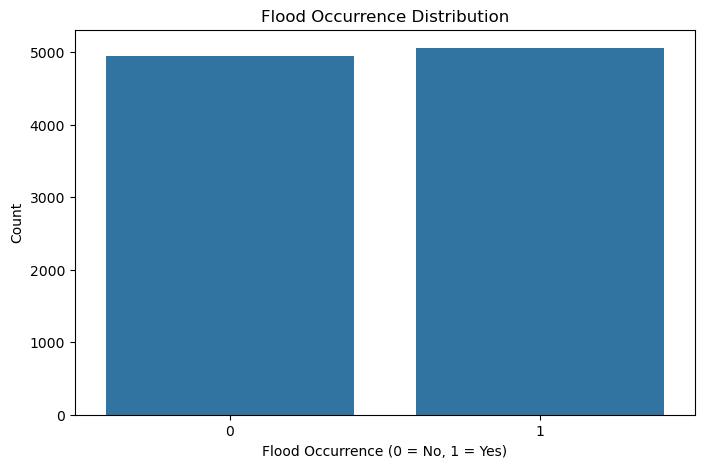

In [9]:
plt.figure(figsize=(8, 5))

sns.countplot(
    x="Flood Occurred",
    data=data
)

plt.xlabel("Flood Occurrence (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.title("Flood Occurrence Distribution")

plt.show()

In [11]:
print(data["Land Cover"].value_counts())

Land Cover
Water Body      2046
Desert          2033
Forest          2005
Agricultural    1978
Urban           1938
Name: count, dtype: int64


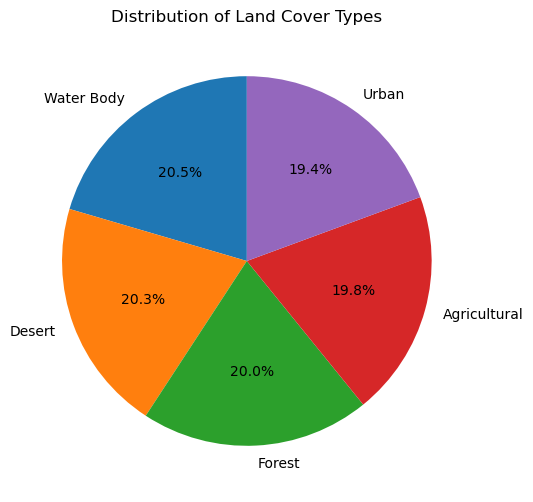

In [12]:
plt.figure(figsize=(8, 6))

data["Land Cover"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Land Cover Types")
plt.ylabel("")

plt.show()

In [13]:
print(data["Soil Type"].value_counts())

Soil Type
Peat     2052
Silt     2044
Clay     1978
Loam     1972
Sandy    1954
Name: count, dtype: int64


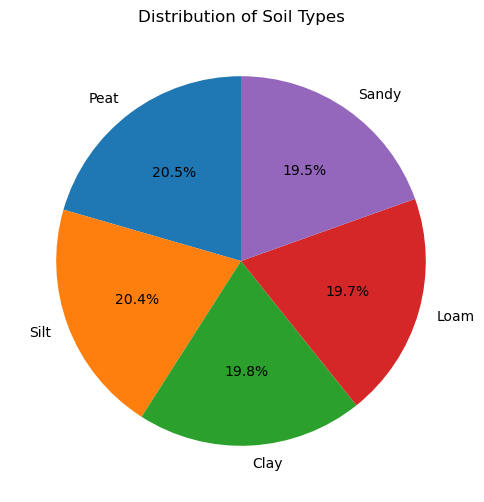

In [14]:
plt.figure(figsize=(8, 6))

data["Soil Type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Soil Types")
plt.ylabel("")

plt.show()

In [15]:
numerical_features = data[
    [
        "Rainfall (mm)",
        "Temperature (°C)",
        "Humidity (%)",
        "River Discharge (m³/s)",
        "Water Level (m)",
        "Elevation (m)",
        "Population Density"
    ]
]

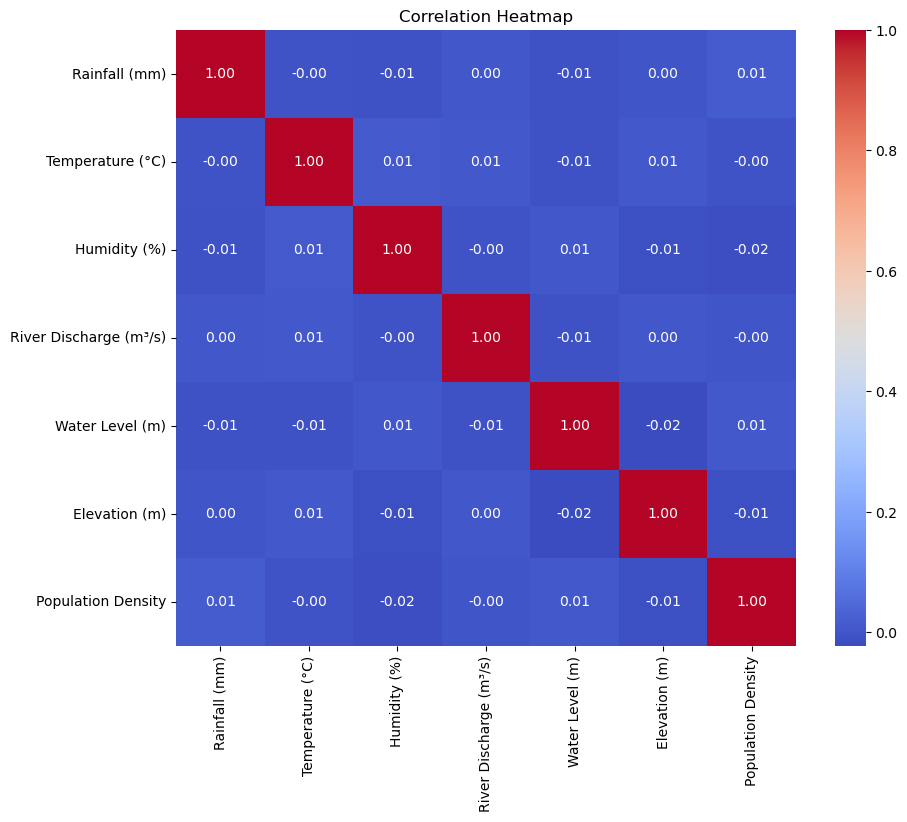

In [16]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    numerical_features.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [17]:
encoded_data = pd.get_dummies(
    data,
    columns=["Land Cover", "Soil Type"]
)

In [18]:
print(encoded_data.head())
print(encoded_data.shape)

    Latitude  Longitude  Rainfall (mm)  Temperature (°C)  Humidity (%)  \
0  18.861663  78.835584     218.999493         34.144337     43.912963   
1  35.570715  77.654451      55.353599         28.778774     27.585422   
2  29.227824  73.108463     103.991908         43.934956     30.108738   
3  25.361096  85.610733     198.984191         21.569354     34.453690   
4  12.524541  81.822101     144.626803         32.635692     36.292267   

   River Discharge (m³/s)  Water Level (m)  Elevation (m)  Population Density  \
0             4236.182888         7.415552     377.465433         7276.742184   
1             2472.585219         8.811019    7330.608875         6897.736956   
2              977.328053         4.631799    2205.873488         4361.518494   
3             3683.208933         2.891787    2512.277800         6163.069701   
4             2093.390678         3.188466    2001.818223         6167.964591   

   Infrastructure  ...  Land Cover_Agricultural  Land Cover_Desert  

In [20]:
features = encoded_data.drop(
    columns=[
        "Flood Occurred",
        "Latitude",
        "Longitude"
    ]
)

target = encoded_data["Flood Occurred"]

In [21]:
print("Features shape:", features.shape)
print("Target shape:", target.shape)

Features shape: (10000, 19)
Target shape: (10000,)


In [22]:
features_train, features_test, target_train, target_test = train_test_split(
    features,
    target,
    test_size=0.20,
    random_state=42,
    stratify=target
)

In [23]:
print("Training samples:", len(features_train))
print("Testing samples:", len(features_test))

Training samples: 8000
Testing samples: 2000


In [24]:
scaler = StandardScaler()

features_train_scaled = scaler.fit_transform(features_train)
features_test_scaled = scaler.transform(features_test)

print("Feature scaling completed!")

Feature scaling completed!


In [25]:
rf_model = RandomForestClassifier(
    random_state=42,
    n_estimators=200
)

rf_model.fit(
    features_train_scaled,
    target_train
)

print("Random Forest training completed!")

Random Forest training completed!


In [26]:
predictions = rf_model.predict(features_test_scaled)

accuracy = accuracy_score(
    target_test,
    predictions
)

print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 50.45%


In [27]:
print(
    classification_report(
        target_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.50      0.47      0.49       989
           1       0.51      0.54      0.52      1011

    accuracy                           0.50      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.50      0.50      0.50      2000



In [28]:
probabilities = rf_model.predict_proba(
    features_test_scaled
)

print(probabilities[:5])

[[0.495 0.505]
 [0.51  0.49 ]
 [0.47  0.53 ]
 [0.52  0.48 ]
 [0.375 0.625]]


In [29]:
flood_probabilities = probabilities[:, 1]

print(flood_probabilities[:10])

[0.505 0.49  0.53  0.48  0.625 0.5   0.555 0.48  0.485 0.37 ]


In [30]:
input_data = pd.DataFrame({
    "Rainfall (mm)": [150],
    "Temperature (°C)": [30],
    "Humidity (%)": [70],
    "River Discharge (m³/s)": [20000],
    "Water Level (m)": [5],
    "Elevation (m)": [200],
    "Population Density": [5000],
    "Infrastructure": [1],
    "Historical Floods": [1],

    "Land Cover_Agricultural": [1],
    "Land Cover_Desert": [0],
    "Land Cover_Forest": [0],
    "Land Cover_Urban": [0],
    "Land Cover_Water Body": [0],

    "Soil Type_Clay": [0],
    "Soil Type_Loam": [0],
    "Soil Type_Peat": [0],
    "Soil Type_Sandy": [0],
    "Soil Type_Silt": [0]
})

In [32]:
input_data = input_data.reindex(
    columns=features.columns,
    fill_value=0
)

In [33]:
scaled_input = scaler.transform(input_data)

In [34]:
prediction = rf_model.predict(scaled_input)

probability = rf_model.predict_proba(
    scaled_input
)[0][1]

print("Flood prediction:", prediction[0])
print(f"Flood probability: {probability * 100:.2f}%")

Flood prediction: 1
Flood probability: 57.00%


In [35]:
if probability < 0.30:
    risk = "LOW"
elif probability < 0.60:
    risk = "MEDIUM"
elif probability < 0.80:
    risk = "HIGH"
else:
    risk = "VERY HIGH"

print(f"Flood probability: {probability * 100:.2f}%")
print(f"Risk level: {risk}")

Flood probability: 57.00%
Risk level: MEDIUM


In [36]:
import joblib

joblib.dump(
    rf_model,
    "flood_risk_model.pkl"
)

joblib.dump(
    scaler,
    "flood_risk_scaler.pkl"
)

joblib.dump(
    list(features.columns),
    "flood_feature_columns.pkl"
)

print("Model and preprocessing objects saved!")

Model and preprocessing objects saved!
